In [1]:
import numpy as np
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
!wget 'https://cdn.pixabay.com/photo/2023/09/02/15/03/lynx-8229077_1280.png'

"wget" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.


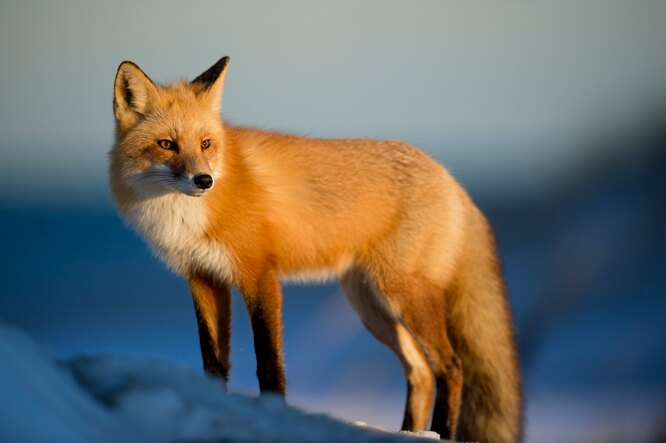

In [6]:
image = Image.open('123343.jpg')
image

# RGB

Мы загрузили из интернета картинку `854x1280` и прочитали ее с помощью библиотеки `PIL`. Любое изображение, с точки зрения данных, представляет собой числовой массив, который может быть представлен в виде числовой таблицы или матрицы, где каждый элемент кодирует тот или иной пиксель. Но есть, как говорится, нюанс! В случае, когда наша картинка цветная, чаще всего она может быть представлена в виде трех матриц, или трехмерной матрицы, каждая из которых кодирует один из трех каналов:

* R - красный
* G - зеленый
* B - синий

Если мы говорим о 8-ми битной кодировки, то в каждом канале каждый пиксель может принимать целые значение от 0 до 255. Это значение показывает интенсивность (яркость) цвета для одного из каналов RGB или яркость белого для ЧБ изображения (одноканального). Как известно, чтобы закодировать число 256 в двоичном виде - нулями и единицами, нужно 8 знаков. Поэтому мы говорим о 8-мибитном изображении.

Ниже дан калькулятор RGB. Поиграйтесь им!

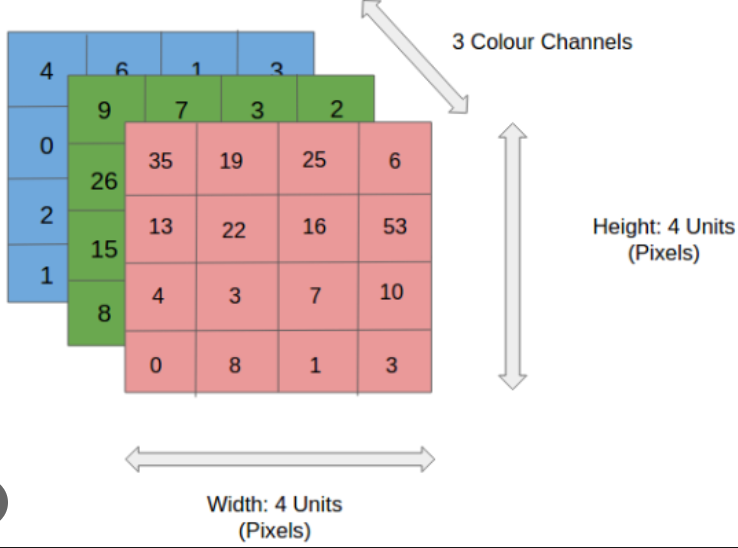

In [7]:
#@title code
import ipywidgets as widgets
from IPython.display import display, clear_output
slider_r = widgets.FloatSlider(
    value=0,
    min=0,
    max=255,
    step=1,
    description='Красный:'
)
slider_g = widgets.FloatSlider(
    value=0,
    min=0,
    max=255,
    step=1,
    description='Зеленый:'
)
slider_b = widgets.FloatSlider(
    value=0,
    min=0,
    max=255,
    step=1,
    description='Синий:'
)

def update_rgb_image(r_value, g_value, b_value):
    width, height = 200, 200
    rgb_image = np.zeros((height, width, 3), dtype=np.uint8)

    r = int(r_value)
    g = int(g_value)
    b = int(b_value)

    rgb_image[:, :, 0] = r
    rgb_image[:, :, 1] = g
    rgb_image[:, :, 2] = b

    image = Image.fromarray(rgb_image)

    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.title(f'RGB изображение')
    plt.axis('off')
    plt.show()


out = widgets.Output()


def on_slider_change(change):
    r_value = slider_r.value
    g_value = slider_g.value
    b_value = slider_b.value

    with out:
        clear_output(wait=True)
        update_rgb_image(r_value, g_value, b_value)

slider_r.observe(on_slider_change, 'value')
slider_g.observe(on_slider_change, 'value')
slider_b.observe(on_slider_change, 'value')
display(widgets.VBox([slider_r, slider_g, slider_b]))
display(out)

Output()

# Image -> List

In [8]:
rgb_matrix = np.array(image)

In [9]:
rgb_matrix.shape

(443, 666, 3)

In [10]:
r_matrix = rgb_matrix[:,:,0]
g_matrix = rgb_matrix[:,:,1]
b_matrix = rgb_matrix[:,:,2]

In [11]:
r_matrix

array([[123, 124, 124, ..., 121, 121, 121],
       [124, 124, 124, ..., 121, 121, 121],
       [124, 124, 124, ..., 121, 121, 121],
       ...,
       [ 31,  31,  31, ...,  35,  31,  31],
       [ 30,  30,  30, ...,  33,  30,  30],
       [ 28,  28,  28, ...,  31,  28,  28]], shape=(443, 666), dtype=uint8)

Мы создали три двумерных списка `r_matrix`, `g_matrix` и `b_matrix` размером (854, 1280) каждый для каждого канала по отдельности.

In [12]:
def show_imade(image_: np.ndarray) -> Image.Image:
  return Image.fromarray(image_.astype(np.uint8))

Для пущей легкости работы, для вас написана функция `show_imade()`, которая вашу матрицу (двумерный list) превращает в картинку и ее показывает. Посмотрите, какое изображение будет сформировано для каждого канала.

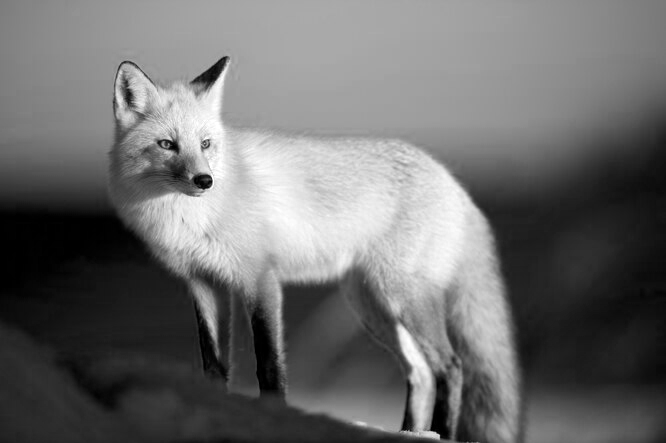

In [16]:
show_imade(r_matrix)

# Задача.

Мы посмотрели на изображение каждого канала. Мы увидели, что один канал будет всегда интерпретироваться как черно-белое изображение, но все полученные картинки немного отличаются между собой, а поэтому считать каждое изображение самостоятельным не очень правильно.

Подумайте, как из исходного трехканального изображения `rgb_matrix` cделать одноканальное, которое будет интерпретироваться как полноценное черно-белое изображение?

Сохраните полученный числовой массив в переменную `b_w_matrix`.

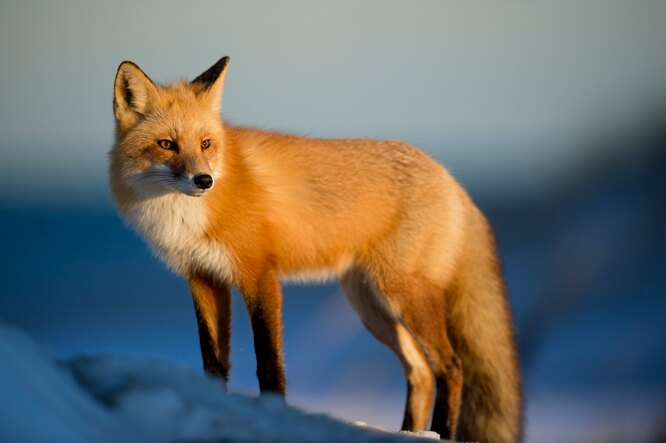

In [17]:
show_imade(rgb_matrix)

In [21]:
b_w_matrix = rgb_matrix.mean(axis =2)


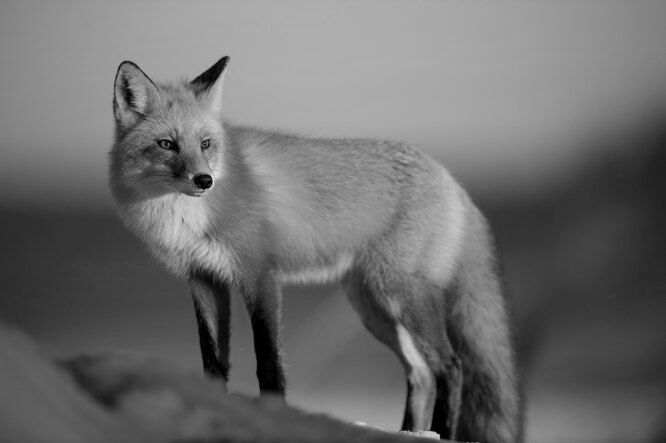

In [22]:
show_imade(b_w_matrix)

# Задача

Обрежьте изображение справа, сделав его размер (854, 1029)

In [23]:
rgb_matrix.shape

(443, 666, 3)

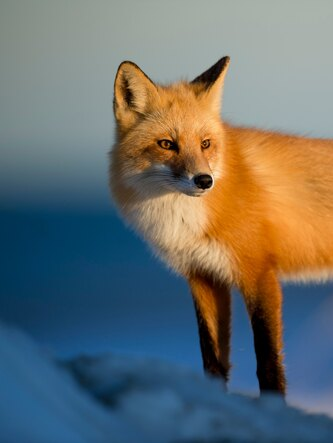

In [24]:
show_imade(rgb_matrix[:, :333, :])

# Задача

Сделайте для этой картинки уменьшенную копию сжав ее в 7 раз. Для этого стоит разбить нашу матрицу на блоки размером 7*7 и для каждого блока пикселей найти среднее арифметическое. Это очевидно приведет к ухудшению качества, но в нашей задаче это не критично. Решите задачу итеративно.

In [41]:
rgb = rgb_matrix[2:440].copy()

In [42]:
rgb.shape

(438, 666, 3)

In [74]:
(438/6) * (666/6)

8103.0

In [69]:
l = list()

In [70]:
for i in range(6, rgb.shape[0]+1, 6):
    for j in range(6, rgb.shape[1]+1, 6):
        l.append(rgb[i-6:i, j-6: j].mean(axis = (0,1)))

In [71]:
res = np.array(l)

In [78]:
res1 = res.reshape(73, -1, 3 , order = 'C')

In [79]:

res1.shape

(73, 111, 3)

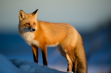

In [80]:
show_imade(res1)